# PSD for OU process


This notebook compares the PSD defined by an OU process with in the PSD that is typically used in pulsar timing for both pulsar timing noise and the GW background.

We then use these comparisons to set approximate, order-of-magnitude estimates on typical values of our model parameters.

The "traditional" PSD typically used by pulsar people has the same form (i.e. a power law) for both timing noise and the stochastic GW background


$$ P(f) = \frac{A^2}{12 \pi^2} \left( \frac{f}{f_{\text{yr}}}\right)^{-\alpha} [\text{Units: } \text{yr}^{3}]$$ 

Note that sometimes the amplitude is defined differently, with the $12\pi^2$ factor being absorbed, e.g Equation 14 of [Chamberlin et al. 2014](https://arxiv.org/abs/1410.8256), although the modern convention seems to be to leave the factor unabsorbed, e.g. [Reardon et al. 2023](https://arxiv.org/abs/2306.16215). The convention is also to have the amplitude $A$ be _dimensionless_ and the PSD to have units of yr$^3$. When people quote the PSD amplitude in the literature they are referring to this dimensionless amplitude - this will be important to note later w.r.t unit conversion. 

Some other useful literature:
* https://github.com/vallis/libstempo/blob/master/libstempo/toasim.py#L298 
* Equation 7.13 (mind the units!) from https://arxiv.org/pdf/2105.13270 
* Equation 1 in https://arxiv.org/pdf/2306.16229


---

# Derivation of PSD for Time Fluctuations from Ornstein-Uhlenbeck Process

## Starting with the Ornstein-Uhlenbeck SDE
We begin with the Ornstein-Uhlenbeck stochastic differential equation:

$$\frac{dx}{dt} = -\gamma x + \chi(t;\sigma)$$

where $\chi(t;\sigma)$ is white noise with standard deviation $\sigma$.

## PSD of the Ornstein-Uhlenbeck process
Converting to the frequency domain using the Fourier transform:

$$i\omega\tilde{x}(\omega) = -\gamma\tilde{x}(\omega) + \tilde{\chi}(\omega)$$

Solving for $\tilde{x}(\omega)$:

$$\tilde{x}(\omega) = \frac{\tilde{\chi}(\omega)}{i\omega + \gamma}$$

The PSD of $x$ is then:

$$S_x(\omega) = |\tilde{x}(\omega)|^2 = \frac{|\tilde{\chi}(\omega)|^2}{|i\omega + \gamma|^2} = \frac{\sigma^2}{\omega^2 + \gamma^2}$$

Converting to frequency $f$ where $\omega = 2\pi f$:

$$S_x(f) = \frac{\sigma^2}{(2\pi f)^2 + \gamma^2}$$

This can be rewritten as:

$$S_x(f) = \frac{\sigma^2/\gamma^2}{1 + (f/f_c)^2}$$

where $f_c = \gamma/(2\pi)$ is the corner frequency.

## PSD of phase fluctuations $\phi$
Given that $\frac{d\phi}{dt} = x$, in the frequency domain:

$$\tilde{x}(f) = i2\pi f \cdot \tilde{\phi}(f)$$

For power spectral densities, this means:

$$S_x(f) = (2\pi f)^2 \cdot S_{\phi}(f)$$

Rearranging and substituting the expression for $S_x(f)$:

$$S_{\phi}(f) = \frac{S_x(f)}{(2\pi f)^2} = \frac{\sigma^2/\gamma^2}{(2\pi f)^2 \cdot [1 + (f/f_c)^2]}$$

Simplifying:

$$S_{\phi}(f) = \frac{\sigma^2}{\gamma^2} \cdot \frac{1}{(2\pi f)^2 [1 + (f/f_c)^2]}$$

## PSD of time fluctuations $\delta t$
Given $\delta t = \phi/f_0$ where $f_0$ is a constant:

$$S_{\delta t}(f) = \left(\frac{1}{f_0}\right)^2 \cdot S_{\phi}(f)$$

Substituting the expression for $S_{\phi}(f)$:

$$S_{\delta t}(f) = \frac{\sigma^2}{(f_0\gamma)^2(2\pi)^2} \cdot \frac{1}{f^2 [1 + (f/f_c)^2]}$$

With $f_c = \gamma/(2\pi)$ remaining the corner frequency.

This PSD has:
- A $1/f^2$ behavior at low frequencies ($f \ll f_c$)
- A $1/f^4$ behavior at high frequencies ($f \gg f_c$)
- Units of s²/Hz



Note that the paper quotes a denominator of 48. I think this is wrong and it should actually be 24. **Edit** in the paper we haev two different expressions for $\sigma^2$. In Equation 19, we have it over 6, in equation A25, we have it over 12.

In [1]:
import numpy as np



# Constants and unit conversions
seconds_per_year = 365.25 * 24 * 60 * 60  # seconds in a year

def power_law_psd(f, A, alpha):
    """Traditional PSD model: P(f) = A^2/(12*pi^2) * (f/f_ref)^(-alpha) [yr^3]"""

    #First calculate in yr^{3}
    f_ref = 1/seconds_per_year
    psd_yr = (A**2 / (12 * np.pi**2)) * (f / f_ref)**(-alpha) 

    # Converting from yr^3 to s^3 for consistency
    return psd_yr * seconds_per_year**3


def ou_psd(f, sigma, gamma):
    """PSD derived from OU process: S_delta_t(f) = sigma^2/((f0*gamma)^2*(2*pi)^2) * 1/(f^2[1 + (f/fc)^2]) for pulsar timing noise"""
    fc = gamma / (2 * np.pi)
    return (sigma**2 / (gamma**2 * (2 * np.pi)**2)) * (1 / (f**2 * (1 + (f/fc)**2))) 
    #This is a "general" form for the PSD of the OU process, which can be used for both pulsar timing noise and the GW background. The TN needs a correction of f0^2.





### Timing noise 

Text(0, 0.5, 'P(f) [s^3]')

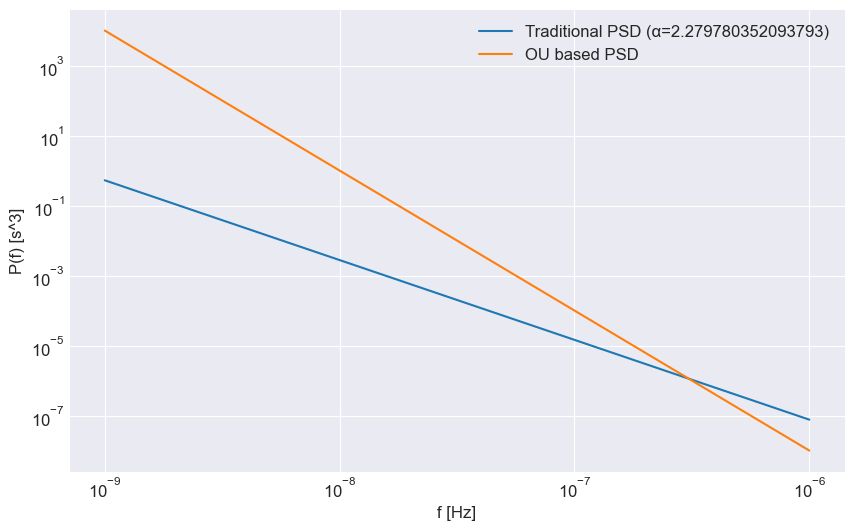

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatter
import matplotlib as mpl





f_range = np.logspace(-9,-6,10)

#PSD
## J0751+1807
A = 10**(-12.051650919621114)  # Example amplitude. See https://github.com/ipta/mdc2/blob/master/group1/group1_psr_noise.json
alpha = 2.279780352093793
psd_trad = power_law_psd(f_range,A,alpha) #units of s^3

#OU
f0 = 34.657407
psd_ou = ou_psd(f=f_range,sigma=1.4e-13,gamma=1e-13) / f0**2 #units of s^3



#Plot
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.figsize'] = [10, 6]
mpl.rcParams['font.size'] = 12


plt.loglog(f_range, psd_trad, label=f'Traditional PSD (α={alpha})')
plt.loglog(f_range, psd_ou, label=f'OU based PSD')
plt.legend()
plt.xlabel('f [Hz]')
plt.ylabel('P(f) [s^3]')

### Gravitational waves.

The GW PSD has the same form, just with different amplitude and exponent. Lets see how that looks:

gamma =  1.6964600329384883e-09


Text(0, 0.5, 'P(f) [s^3]')

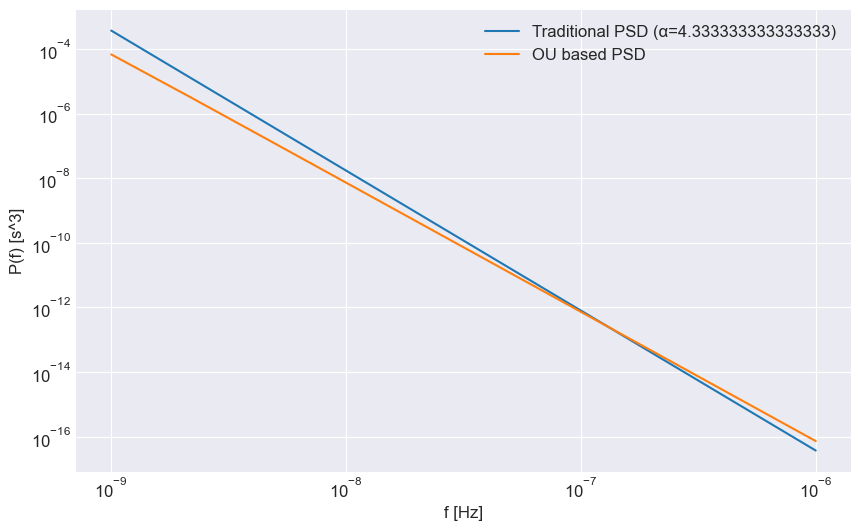

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatter
import matplotlib as mpl





f_range = np.logspace(-9,-6,10)

#PSD
A = 10**(-15.18) # Example amplitude. https://github.com/ipta/mdc2/blob/master/group1/group1_gw_parameters.json
alpha = 13/3
psd_trad = power_law_psd(f_range,A,alpha) #units of s^3

#OU
gamma = 2*np.pi*1e-8 # e-10
fmin = 1e-8
gamma = 2.7e-2 * 2*np.pi*fmin
print("gamma = ", gamma)
ha = 2e-14
sigma = ha*np.sqrt(gamma/6)#See Equation 19 of https://academic.oup.com/mnras/article/537/2/1282/7954752. Ignoring any HD corrections, just for order of magngiude estimates.

psd_ou = ou_psd(f=f_range,sigma=sigma,gamma=gamma) 


#Plot
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.figsize'] = [10, 6]
mpl.rcParams['font.size'] = 12


plt.loglog(f_range, psd_trad, label=f'Traditional PSD (α={alpha})')
plt.loglog(f_range, psd_ou, label=f'OU based PSD')
plt.legend()
plt.xlabel('f [Hz]')
plt.ylabel('P(f) [s^3]')

# Mock data comparison

In [123]:
def get_par_value(filename, parameter):
    """Get the value of a parameter from a parameter file.
    
    TK note: It feels like there should be a better way to do this, just using the enterprise.pulsar.Pulsar object.
    However, I have not been able to figure out how to do this yet.
    We require F0 as part of the measurement model. 
    I take it as a known parameter.
    """
    with open(filename, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts or parts[0].startswith('#'):  # skip empty or commented lines
                continue
            if parts[0] == parameter:
                return float(parts[1])  # assumes the value is the second item
    return None  # if the parameter isn't found



def objective_function(params, f, y_true,f0):
    sigma, gamma = params
    
    # Calculate the output of your ou_psd function
    y_pred = ou_psd(f, sigma, gamma) / f0**2
    
    # Calculate the mean squared error between predicted and true values


    # Use log space for PSD comparison to handle scale differences
    log_diff = np.log10(y_pred) - np.log10(y_true)
    return np.sum(log_diff**2)  # Return MSE in log space





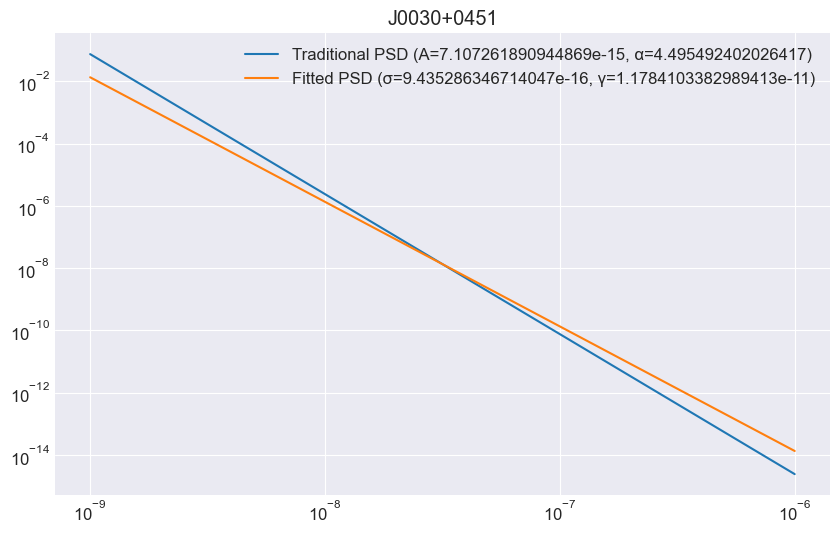

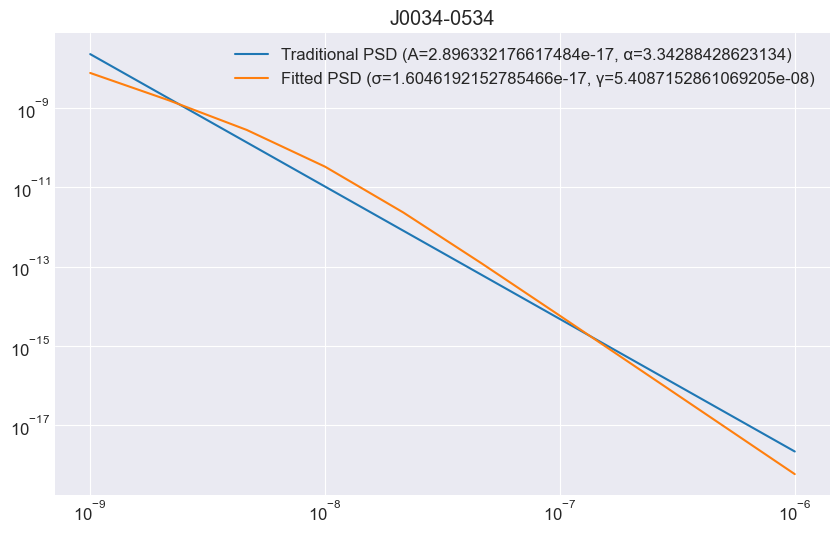

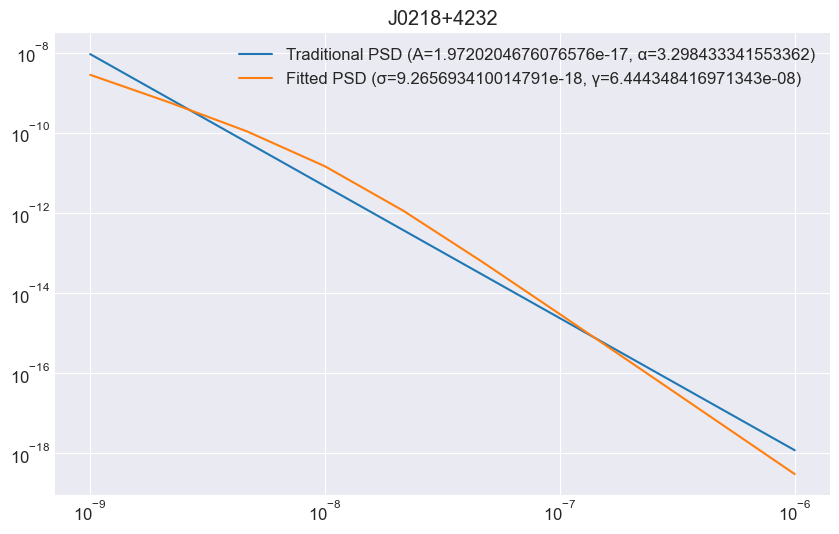

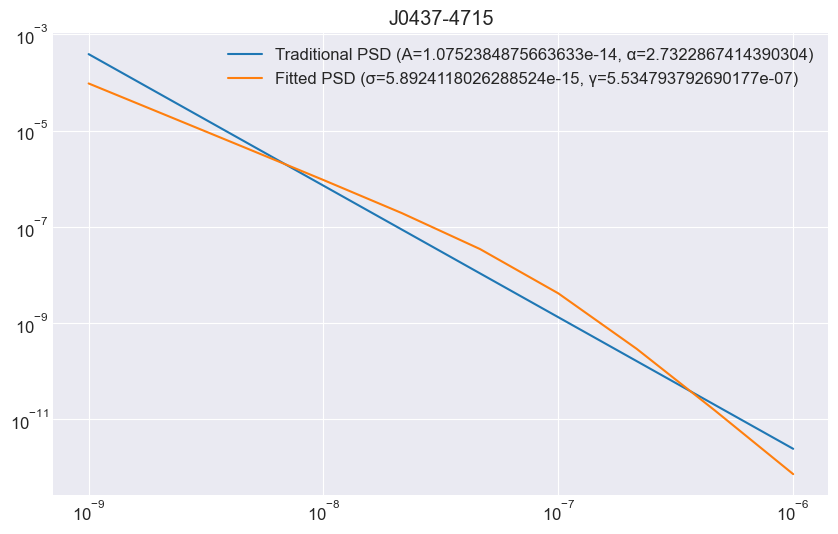

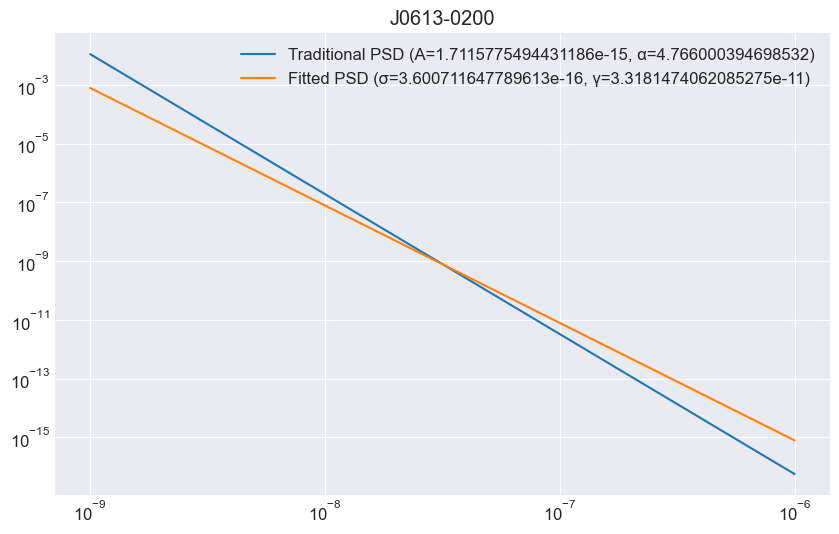

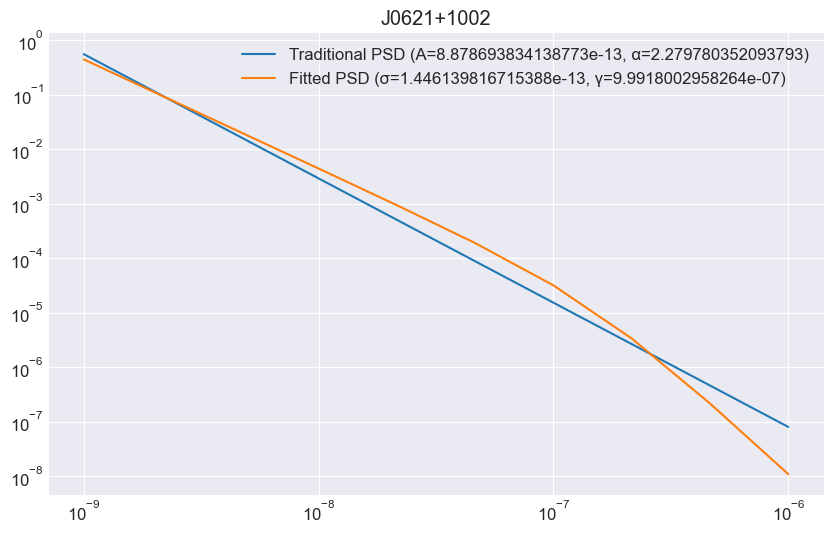

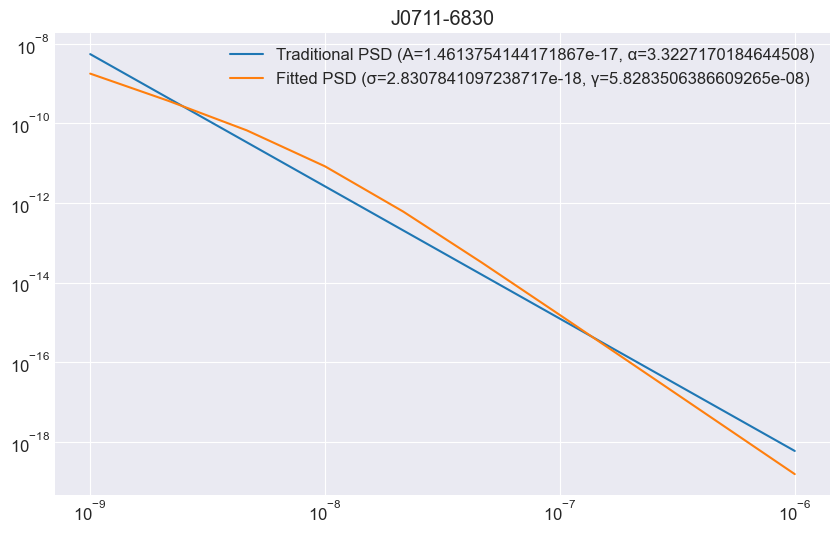

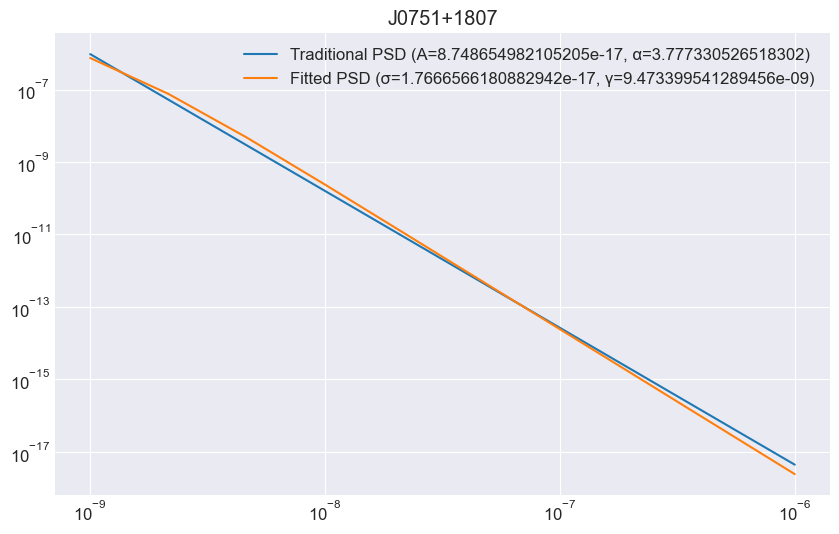

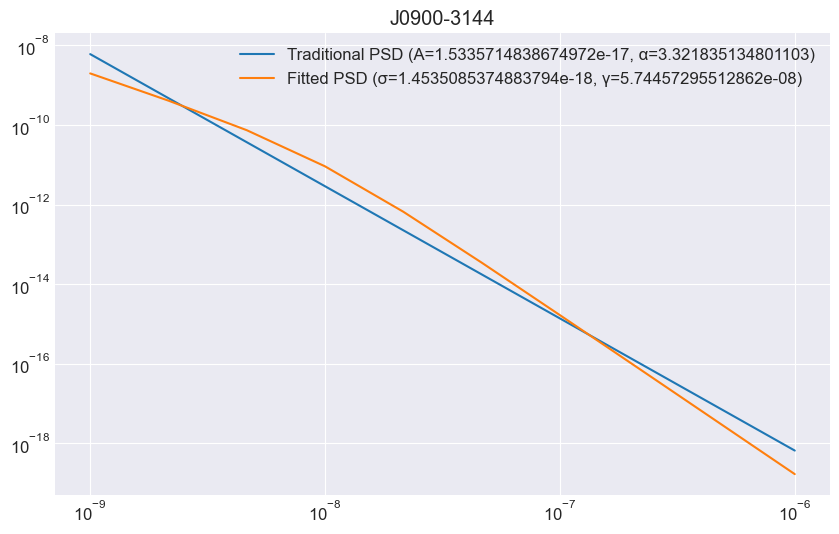

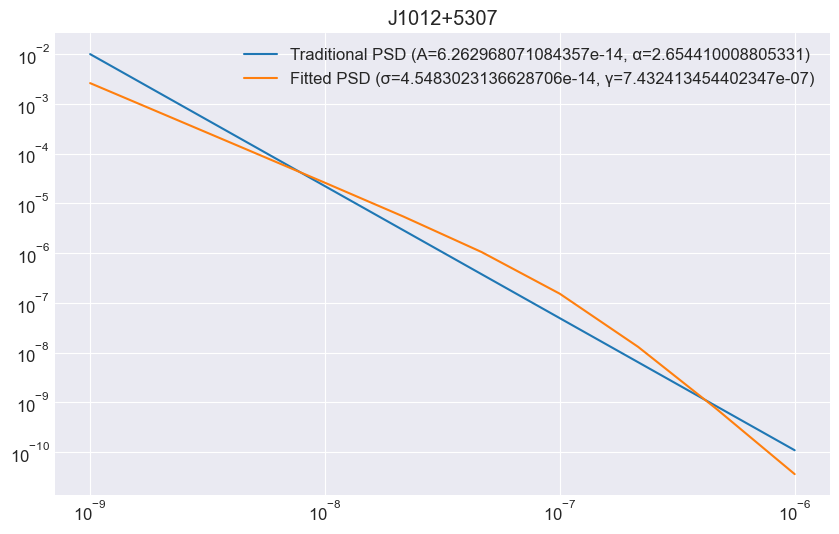

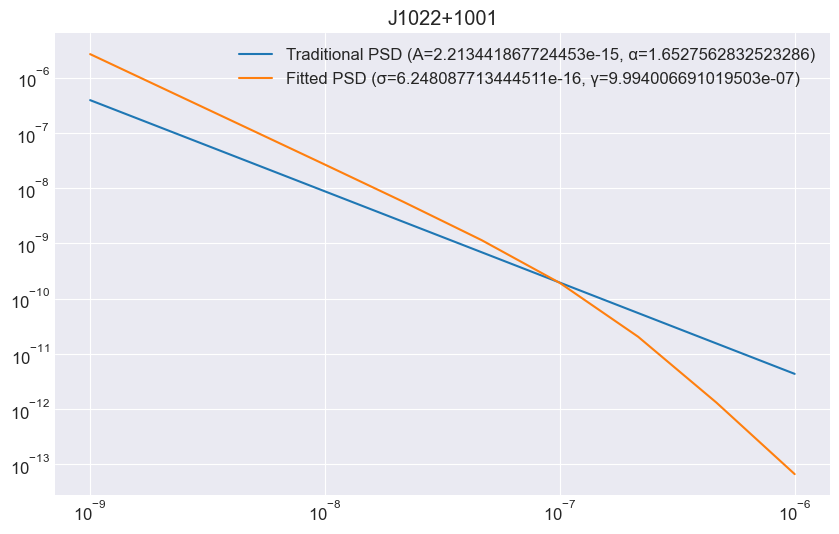

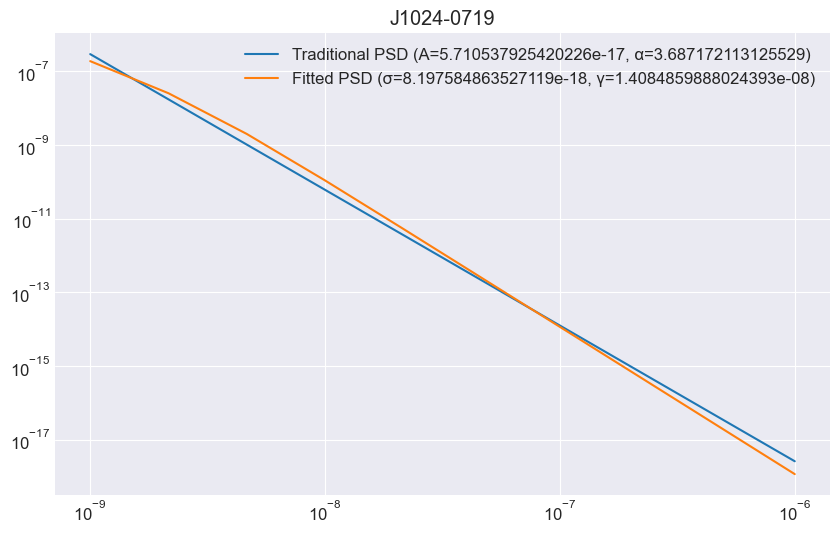

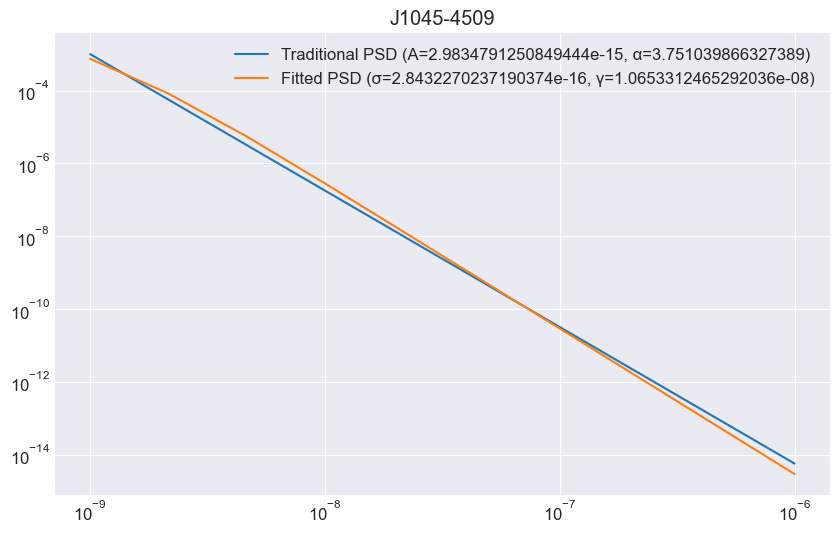

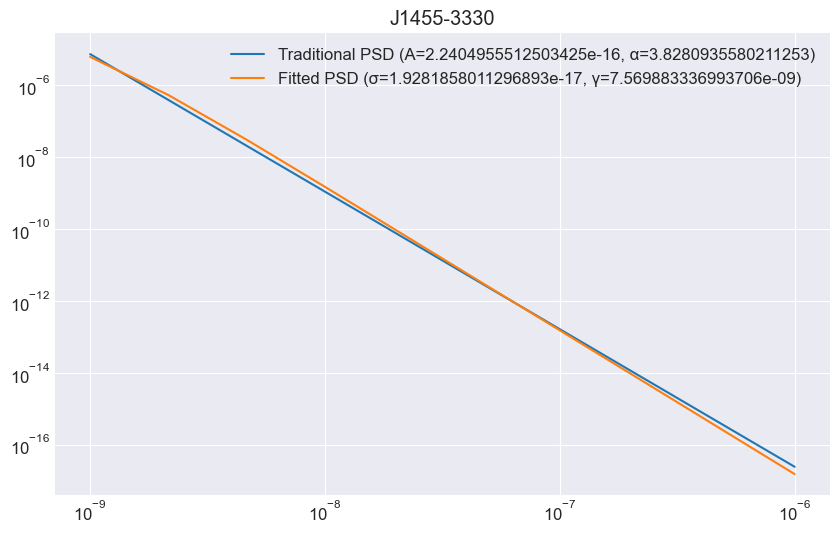

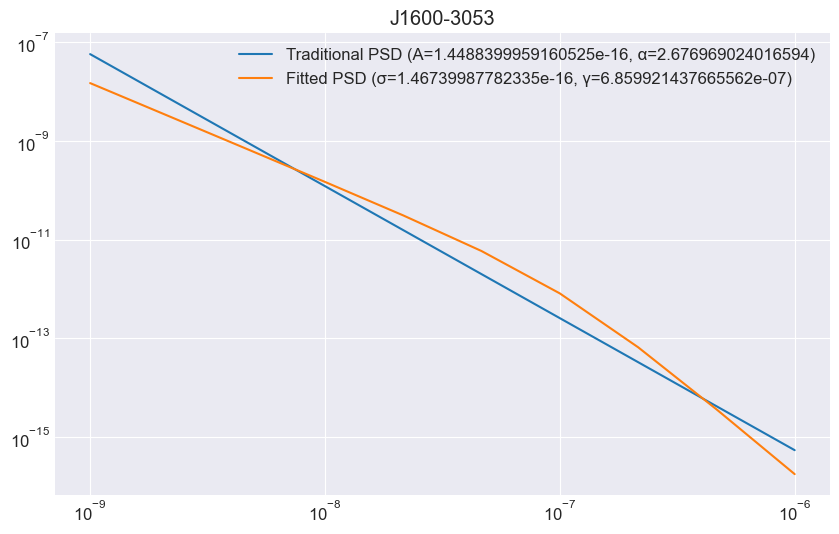

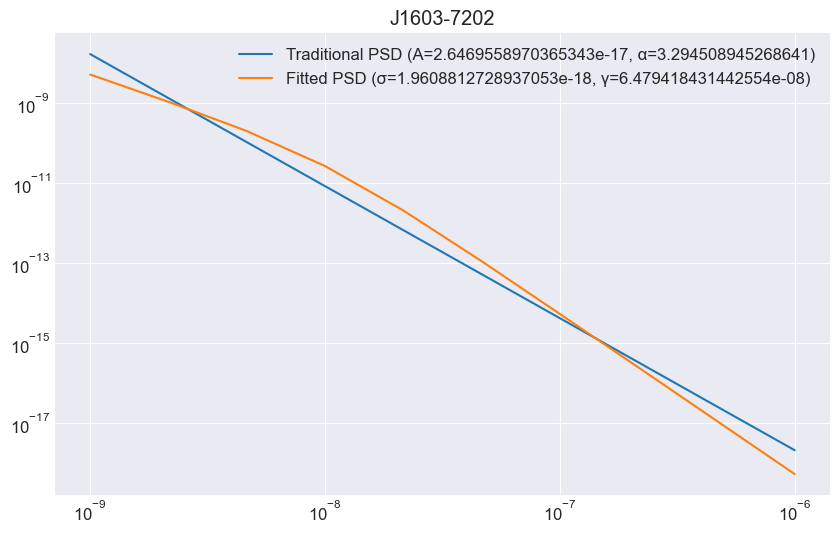

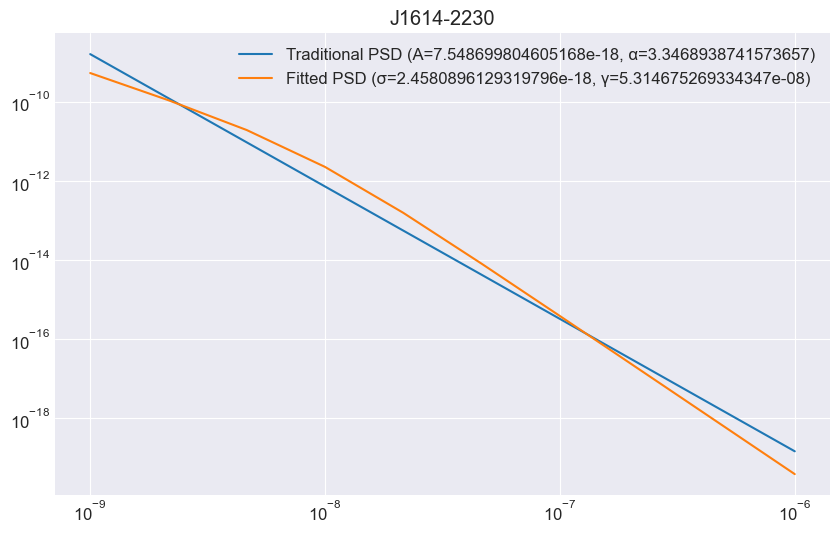

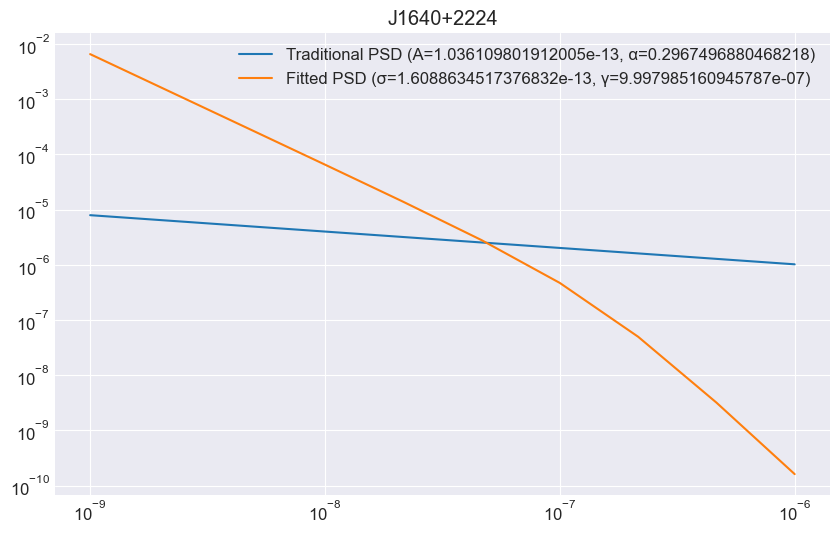

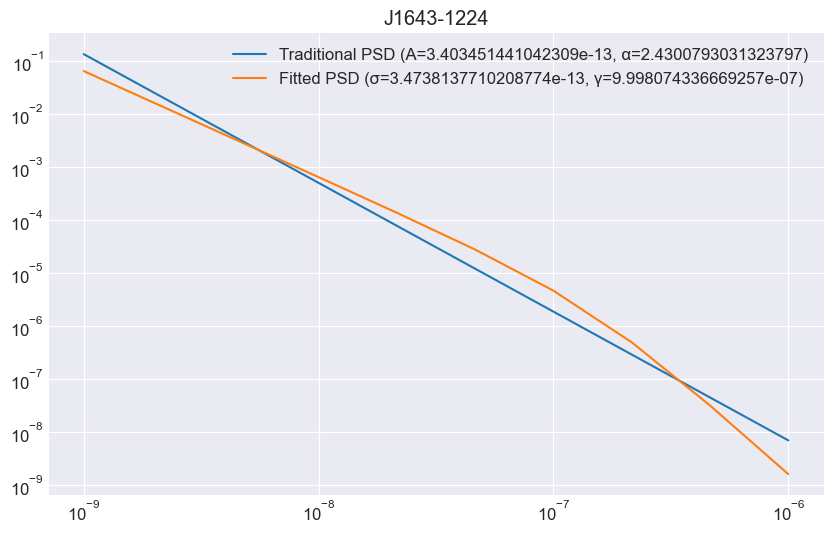

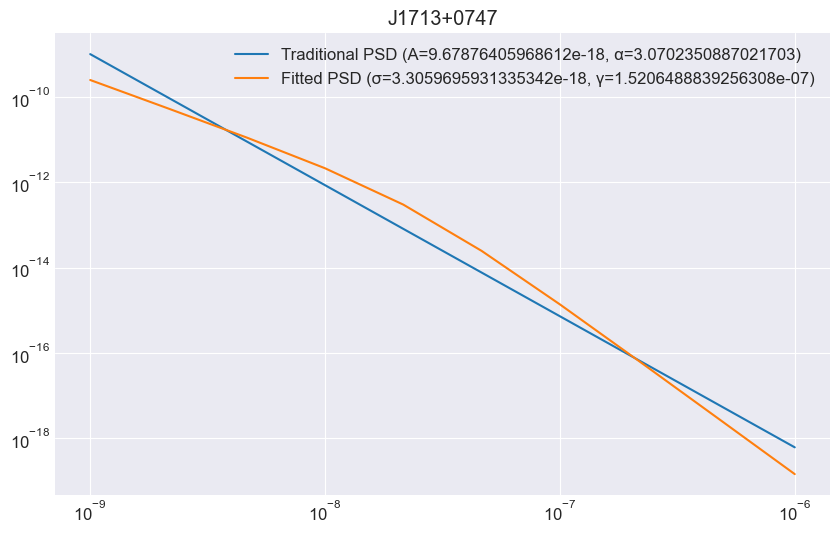

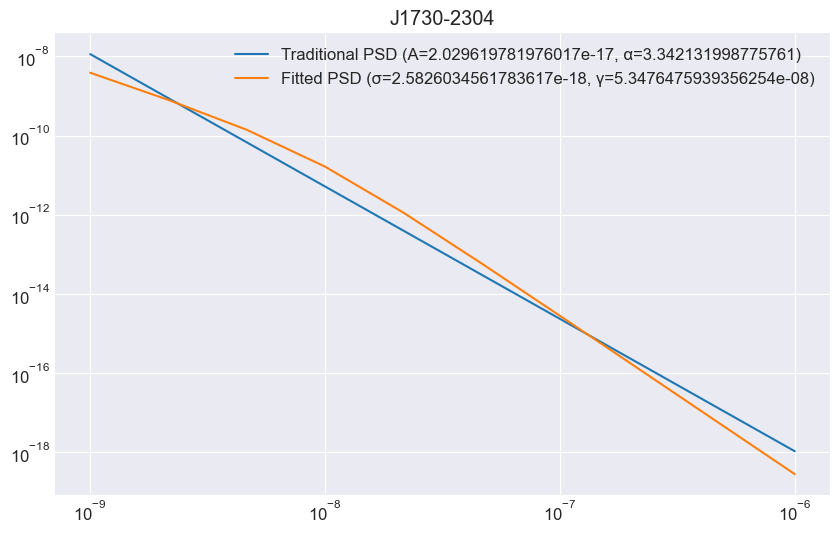

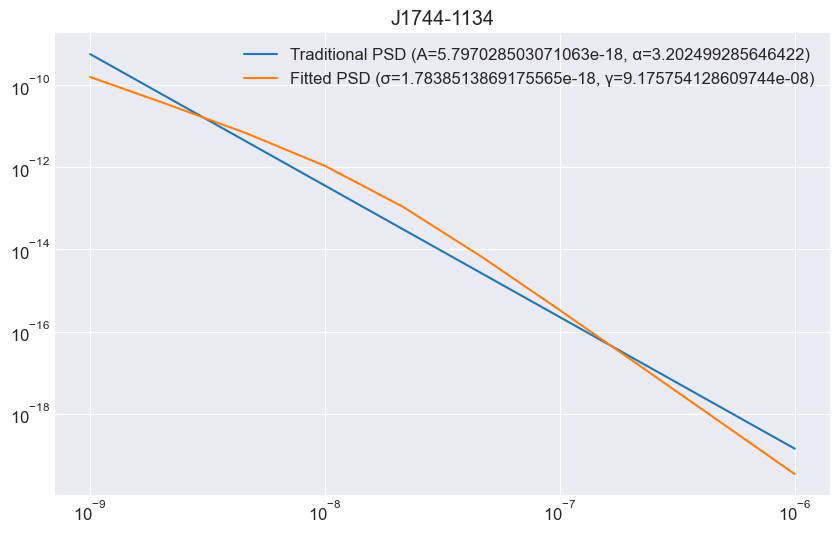

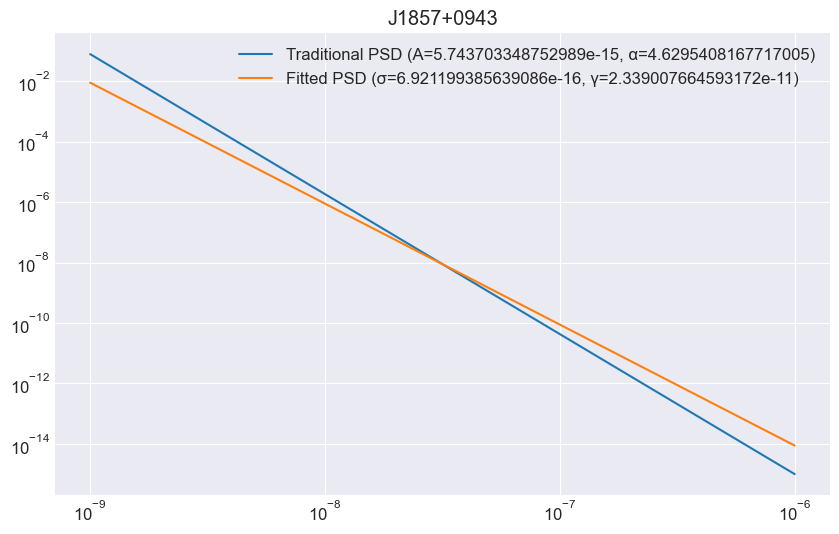

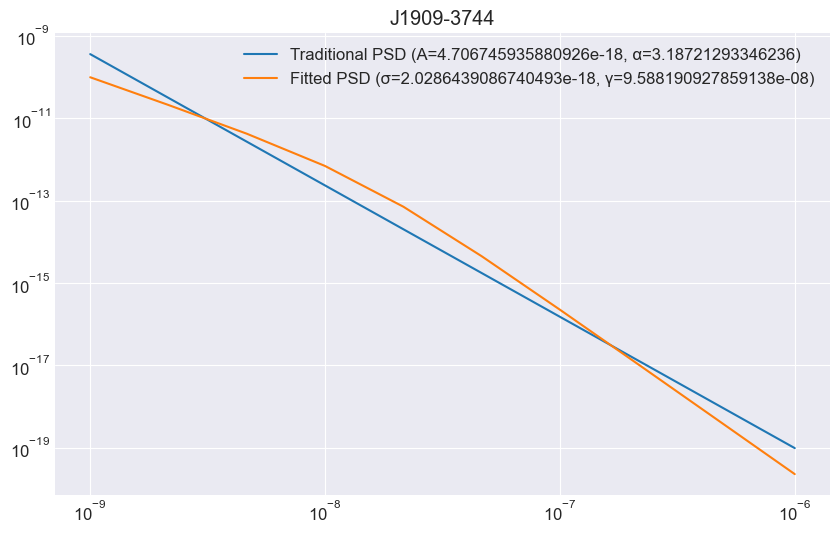

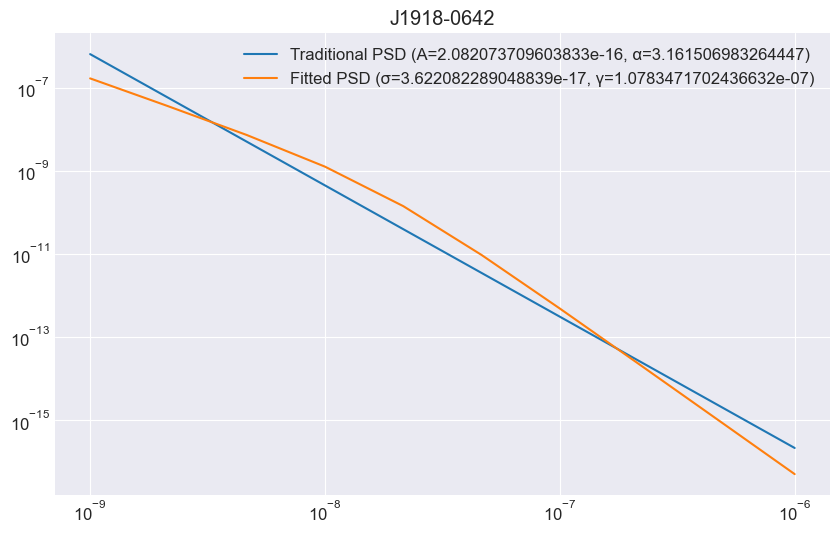

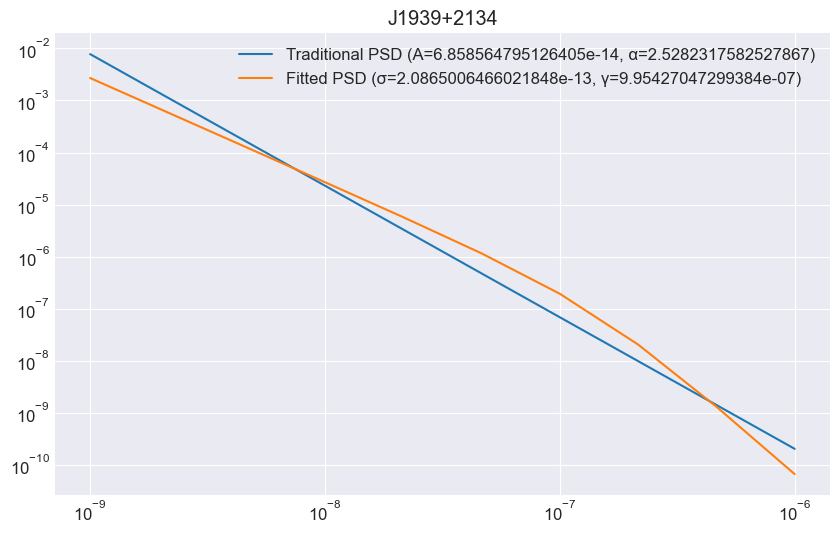

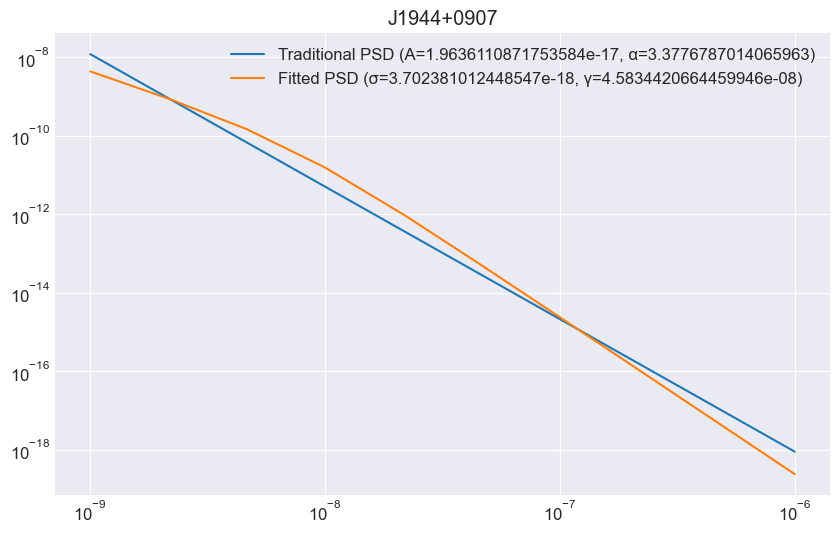

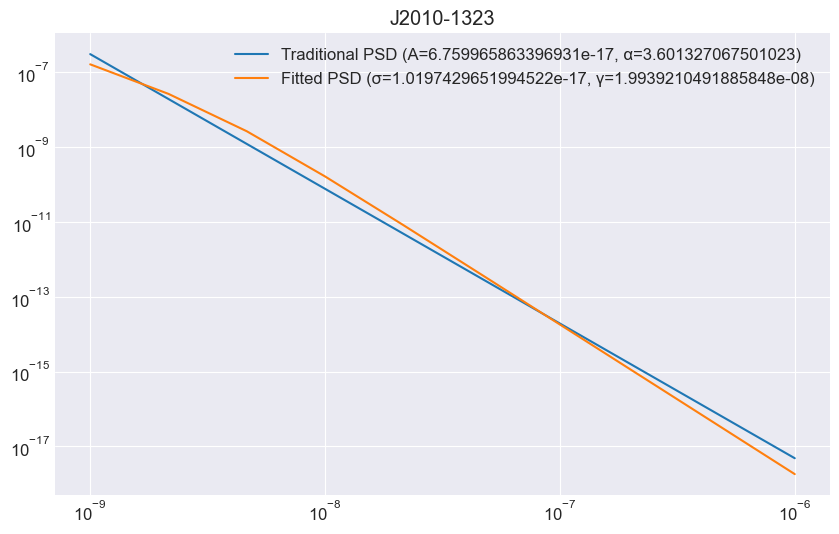

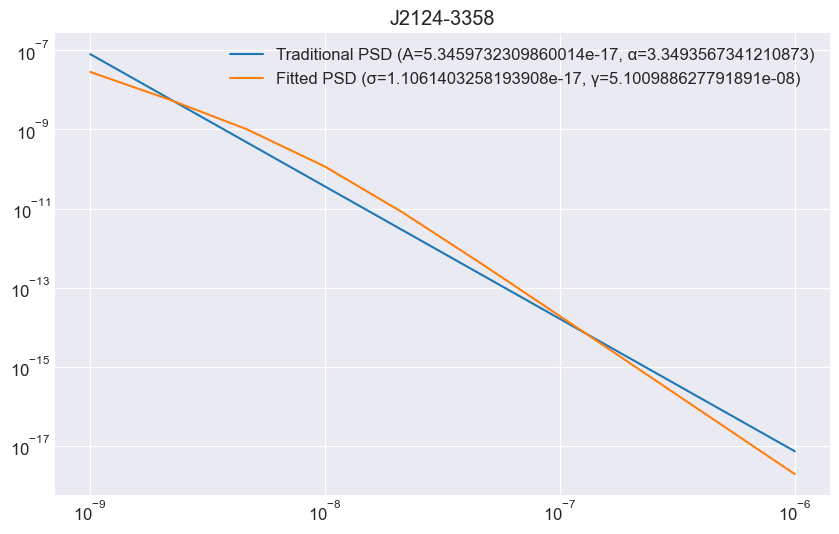

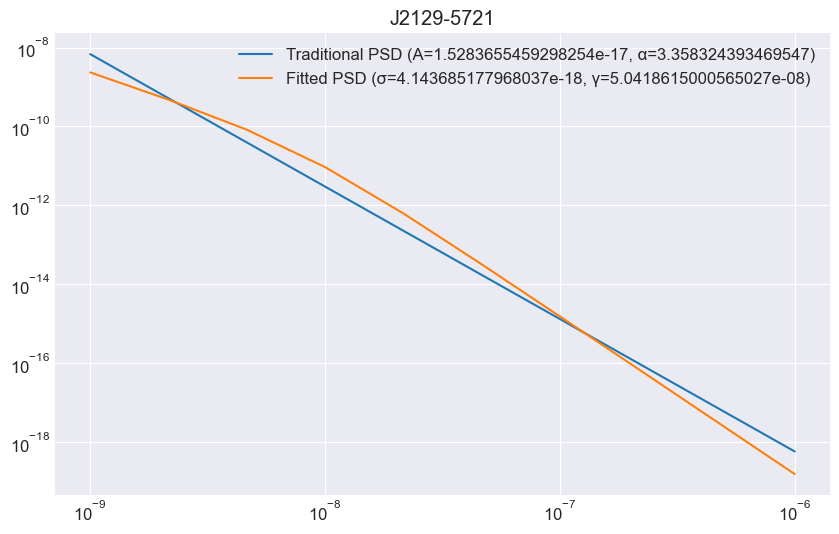

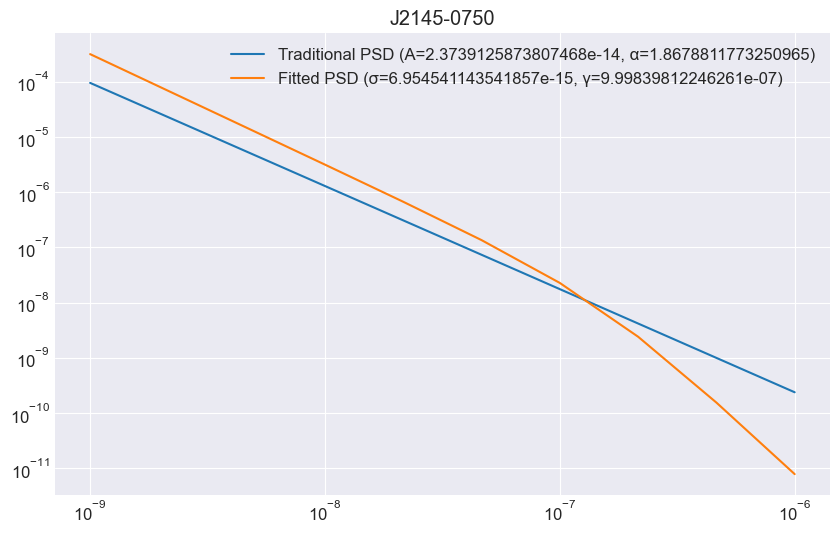

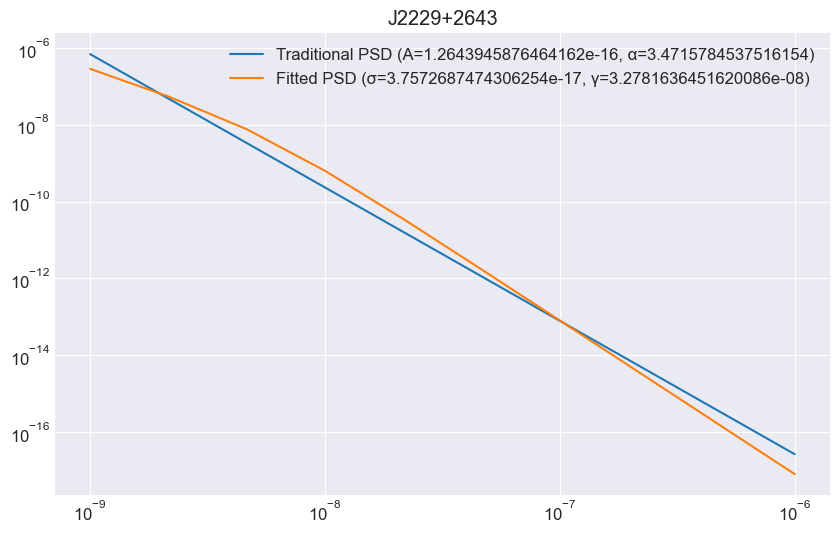

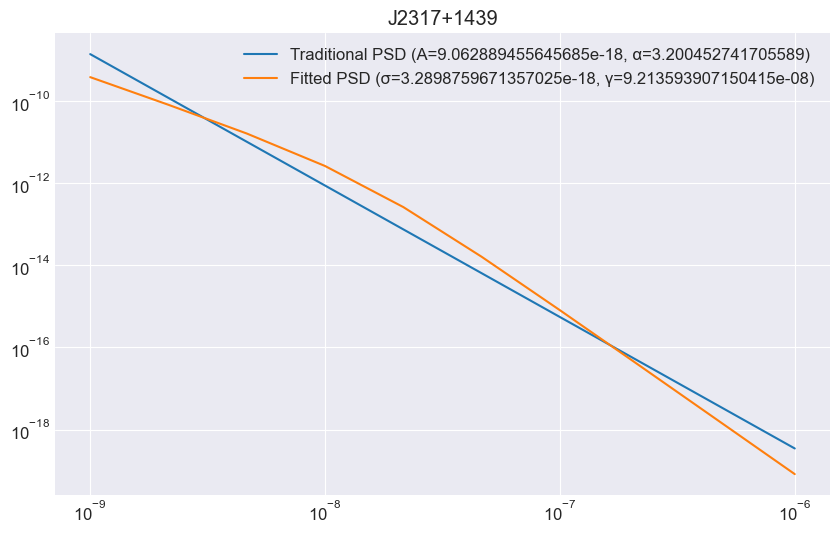

In [159]:
import json 


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatter
import matplotlib as mpl
from itertools import islice
plt.style.use('seaborn-v0_8-darkgrid')
from scipy import optimize
from scipy.optimize import differential_evolution


datadir = "../data/IPTA_MockDataChallenge2/"
f_range = np.logspace(-9,-6,10)


# Initial guess for parameters
initial_params = [1e-15, 1e-13]  # [sigma, gamma]

# Define bounds for parameters (if needed)
bounds = [(1e-25, 1e-5), (1e-15, 1e-6)]  # Both sigma and gamma should be positive



import pandas as pd
data = {
    'psr': [],
    'f0': [],
    'optimal_sigma': [],
    'optimal_gamma': [],
    'result_fun': [],
    'EFAC': [],
    'EQUAD': []
}
with open(datadir + "group1_psr_noise.json", "r") as f:
    psd_data = json.load(f)

    for psr,values in psd_data.items():

        plt.figure()
        f0 = get_par_value(datadir + f"dataset_1b/{psr}.par", "F0")
        #print(psr,f0, values)

        A = 10**(values["rn_log10_A"])
        alpha = values["rn_spec_ind"]
        psd_trad = power_law_psd(f_range,A,alpha) #units of s^3

        
        # Optimize the parameters
        # result = optimize.minimize(
        #     objective_function,
        #     initial_params,
        #     args=(f_range, psd_trad,f0),  # Pass your f values and training data y
        #     bounds=bounds,
        #     method='L-BFGS-B',
        #     options={
        #         'ftol': 1e-15        # Function tolerance (default is ~1e-8)
        #     }
        # )

        result = differential_evolution(
            objective_function,
            bounds,
            args=(f_range, psd_trad, f0),
            strategy='best1bin',
            maxiter=100,
            popsize=15,
            tol=0.01,
            mutation=(0.5, 1.0),
            recombination=0.7,
            updating='immediate',
            disp=False
        )








        # Get the optimized parameters
        optimal_sigma, optimal_gamma = result.x

      

        # Store the values
        data['psr'].append(psr)  # string
        data['f0'].append(float(f0))
        data['optimal_sigma'].append(float(optimal_sigma))
        data['optimal_gamma'].append(float(optimal_gamma))
        data['result_fun'].append(float(result.fun))
        data['EFAC'].append(float(values["efac"]))
        data['EQUAD'].append(float(values["equad"]))

        plt.loglog(f_range, psd_trad, label=f'Traditional PSD (A={A}, α={alpha})')

        y_fitted = ou_psd(f_range, optimal_sigma, optimal_gamma) / f0**2
        plt.loglog(f_range, y_fitted, label=f'Fitted PSD (σ={optimal_sigma}, γ={optimal_gamma})')
        plt.title(psr)
        plt.legend()
        plt.show()


df = pd.DataFrame(data)


# #PSD
# A = 10**(-12.05)  # Example amplitude. See https://github.com/ipta/mdc2/blob/master/group1/group1_psr_noise.json
# alpha = 2.27


# #OU
# f0 = 1/(28e-3)
# psd_ou = ou_psd(f=f_range,sigma=1e-13,gamma=1e-6) / f0**2 #units of s^3





# #Plot
# # Set plot style

# mpl.rcParams['figure.figsize'] = [10, 6]
# mpl.rcParams['font.size'] = 12


# plt.loglog(f_range, psd_trad, label=f'Traditional PSD (α={alpha})')
# plt.loglog(f_range, psd_ou, label=f'OU based PSD')
# plt.legend()
# plt.xlabel('f [Hz]')
# plt.ylabel('P(f) [s^3]')










In [160]:
df

,psr,f0,optimal_sigma,optimal_gamma,result_fun,EFAC,EQUAD
0,J0030+0451,205.530696,9.435286e-16,1.178410e-11,2.250537,1.132705,-6.734253
1,J0034-0534,532.713429,1.604619e-17,5.408715e-08,1.350473,1.259837,-6.641426
2,J0218+4232,430.461055,9.265693e-18,6.444348e-08,1.446068,1.350186,-6.753753
3,J0437-4715,173.687946,5.892412e-15,5.534794e-07,1.506154,0.902789,-7.350188
4,J0613-0200,326.600562,3.600712e-16,3.318147e-11,5.378718,1.069398,-7.049181
5,J0621+1002,34.657407,1.446140e-13,9.991800e-07,1.202970,1.115945,-6.821375
6,J0711-6830,182.117235,2.830784e-18,5.828351e-08,1.394895,1.033147,-7.007095
7,J0751+1807,287.457854,1.766657e-17,9.473400e-09,0.243922,1.098016,-6.783324
8,J0900-3144,90.011842,1.453509e-18,5.744573e-08,1.396704,1.051487,-6.856396
9,J1012+5307,190.267834,4.548302e-14,7.432413e-07,1.343968,1.024449,-6.822630


In [161]:
df.sort_values('psr', ascending=True, inplace=True)

In [162]:
df.to_pickle('spindown_results.pkl')

In [163]:
print("Max sigma: ",df['optimal_sigma'].max())
print("Min sigma: ",df['optimal_sigma'].min())
print("Max gamma: ",df['optimal_gamma'].max())
print("Min gamma: ",df['optimal_gamma'].min())
print("Max EFAC: ",df['EFAC'].max())
print("Min EFAC: ",df['EFAC'].min())
print("Max EQUAD: ",df['EQUAD'].max())
print("Min EQUAD: ",df['EQUAD'].min())


Max sigma:  3.4738137710208774e-13
Min sigma:  1.4535085374883794e-18
Max gamma:  9.99839812246261e-07
Min gamma:  1.1784103382989413e-11
Max EFAC:  2.2058139485827803
Min EFAC:  0.9027892928548922
Max EQUAD:  -6.244756338992644
Min EQUAD:  -7.556289609789052
